# 🛰️ Full Transformer vs UDCMR-Net — Full Training & Visualization

This notebook trains two dual-stream models on Sentinel-2 + EnMAP hyperspectral data:

| Model | Fusion Strategy |
|---|---|
| **Full Transformer** | Repository transformer backbone + simple concatenation fusion |
| **UDCMR-Net** | Repository transformer backbone + TDA alignment + Bayesian gating + Cascade heads |

After training, a comprehensive visualization compares accuracy, loss, per-level OA, and the learned gate weights.

In [6]:
print(torch.__version__)

2.1.1


In [1]:
import torch, transformers
print(torch.__version__)        # should be 2.1.1
print(transformers.__version__) # should be 4.36.2

2.1.1
4.36.2


/home/administrator/anaconda3/envs/1069e/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
import transformers

print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

PyTorch version: 2.1.1
Transformers version: 4.36.2


## 📦 Cell 1 — Imports & Global Config

In [2]:
import os, math, warnings, json, time, sys
warnings.filterwarnings('ignore')
from pathlib import Path
from collections import defaultdict

# Add repo root to import path so notebook can reuse the H2Crop transformer backbone.
sys.path.append(str(Path.cwd()))
from H2Crop.models import SVisionTransformer

import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device : {device}')
print(f'🔢  PyTorch: {torch.__version__}')

ModuleNotFoundError: No module named 'H2Crop'

## 📁 Cell 2 — Paths & Hierarchy

> **Edit `BASE_PATH` below** to point at your local dataset root.  
> Expected layout:
> ```
> BASE_PATH/
>   h5/           ← .h5 scene files
>   data_lists/   ← train_subset.txt / val_subset.txt / test_subset.txt
> ```

In [1]:
# ── ✏️  CHANGE THIS TO YOUR LOCAL PATH ───────────────────────────────────
BASE_PATH = Path(r'../dataset').resolve()
# ─────────────────────────────────────────────────────────────────────────

H5_DIR         = BASE_PATH / 'h5_data'
DATA_LISTS_DIR = BASE_PATH / 'data_list'
SAVE_DIR       = BASE_PATH / 'saved_models'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Hierarchical label counts at each level
HIERARCHY = {0: 6, 1: 36, 2: 82, 3: 101}

# Training hyper-params
BATCH_SIZE  = 4
NUM_EPOCHS  = 100
# Learning rate schedule (paper): warmup from LR_START to LR_MAX over WARMUP_ITERS, then cosine anneal to LR_FINAL
LR_START    = 6e-7
LR_MAX      = 6e-5
LR_FINAL    = 6e-6
WARMUP_ITERS = 1000
D_MODEL     = 256

print(f'📂 Base  : {BASE_PATH}')
print(f'💾 Models: {SAVE_DIR}')

NameError: name 'Path' is not defined

## 📂 Cell 3 — File Loader Utility

In [8]:
def get_files_from_txt(txt_filename: str):
    """Read a .txt list and resolve each entry to its full .h5 path."""
    txt_path = DATA_LISTS_DIR / txt_filename
    if not txt_path.exists():
        print(f'⚠️  {txt_path} not found — skipping.')
        return []

    matched, missing = [], 0
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            name = line.strip().lstrip('\ufeff')
            if not name:
                continue
            p = H5_DIR / f'{name}.h5'
            if p.exists():
                matched.append(p)
            else:
                missing += 1

    if missing:
        print(f'   ⚠️  {missing} entries in {txt_filename} had no matching .h5')
    return matched


train_files = get_files_from_txt('train.txt')
val_files   = get_files_from_txt('val.txt')
test_files  = get_files_from_txt('test.txt')

print(f'\n✅ Loaded  →  Train: {len(train_files)}  |  Val: {len(val_files)}  |  Test: {len(test_files)}')

if len(train_files) == 0:
    raise RuntimeError('No training files found. Check BASE_PATH and .txt contents.')


✅ Loaded  →  Train: 12016  |  Val: 2112  |  Test: 2216


## 🗃️ Cell 4 — Dataset

In [ ]:
class DualStreamDataset(Dataset):
    # Per-channel Sentinel-2 statistics (10 bands × 12 time-steps = 120 channels after reshape)
    S2_MEAN = np.array([4259.26, 4215.91, 4103.17, 4499.33, 5117.05,
                        5324.11, 5487.41, 5417.51, 3758.27, 3095.50], dtype=np.float32)
    S2_STD  = np.array([3566.48, 3230.36, 3133.29, 3083.23, 2603.63,
                        2453.03, 2512.64, 2317.54, 1496.77, 1391.13], dtype=np.float32)

    def __init__(self, file_list, augment: bool = False):
        self.file_list = file_list
        self.augment   = augment

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fpath = self.file_list[idx]
        with h5py.File(fpath, 'r') as f:
            s2    = f['S2_data'][:].astype(np.float32)   # (T, C, H, W)
            label = f['label'][:]
            enmap = (f['EnMAP_data'][:].astype(np.float32)
                     if 'EnMAP_data' in f
                     else np.zeros((218, 64, 64), dtype=np.float32))

        # Normalise S2 per-band and keep temporal dimension: (T, C, H, W)
        s2 = (s2 - self.S2_MEAN[None, :, None, None]) / (self.S2_STD[None, :, None, None] + 1e-8)

        # Normalise EnMAP per-scene
        enmap = (enmap - enmap.mean()) / (enmap.std() + 1e-8)

        # Optional flip augmentation (keep time dimension)
        if self.augment and np.random.rand() > 0.5:
            s2 = np.flip(s2, axis=-1).copy()
            enmap = np.flip(enmap, axis=-1).copy()

        # Majority label per hierarchy level  (ignore background=0)
        labs = []
        for li in range(4):
            vals = label[li][label[li] > 0]
            lab  = (int(np.bincount(vals).argmax()) - 1) if len(vals) > 0 else 0
            labs.append(max(0, lab))

        # Return S2 as (T, C, H, W) (will batch into (B, T, C, H, W))
        return (torch.from_numpy(s2),
                torch.from_numpy(enmap),
                torch.tensor(labs, dtype=torch.long))

Batches  →  Train: 50  |  Val: 528  |  Test: 554


In [ ]:
# Create dataset instances and DataLoaders
train_ds = DualStreamDataset(train_files, augment=True)
val_ds   = DualStreamDataset(val_files,   augment=False)
test_ds  = DualStreamDataset(test_files,  augment=False) if test_files else val_ds

# Balanced sampler on level-0 labels (scan first 200 samples for speed)
scan_n   = min(len(train_ds), 200)
l1_labels = [train_ds[i][2][0].item() for i in range(scan_n)]
cls_w    = 1.0 / (np.bincount(l1_labels, minlength=HIERARCHY[0]) + 1e-6)
s_weights = cls_w[l1_labels]
sampler  = WeightedRandomSampler(s_weights, num_samples=len(s_weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=0)

print(f'Batches  →  Train: {len(train_dl)}  |  Val: {len(val_dl)}  |  Test: {len(test_dl)}')

## 🔧 Cell 5 — Shared Building Blocks

In [ ]:
from H2Crop.models.backbones.video_swin_transformer import SwinPatchEmbed3D, SwinTransformer3D

class RepoTransformerEncoder(nn.Module):
    """Repository-style transformer encoder backbone for S2 / HSI streams."""
    def __init__(self, img_size: int, in_channels: int, d_model: int = 256,
                 patch_size: int = 16, num_heads: int = 8, num_layers: int = 6,
                 out_size: int = None):
        super().__init__()
        if out_size is None:
            out_size = img_size
        self.backbone = SVisionTransformer(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=d_model,
            out_embed_dim=d_model,
            output_size=out_size,
            num_heads=num_heads,
            num_layers=num_layers,
            mlp_ratio=4,
            qkv_bias=True,
            drop_rate=0.0,
            with_cls_token=False,
        )
        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        features = self.backbone(x)
        if isinstance(features, dict):
            features = features.get('ori_feature', features)
        embed = self.pool(features).flatten(1)
        return features, embed


class S23DEncoder(nn.Module):
    """S2 3D encoder wrapper using Swin 3D components.
    Input: (B, T, C, H, W) or (T, C, H, W) per-sample.
    Returns: (features_map (B, C*D, H, W), embed_vector (B, D))
    """
    def __init__(self, in_channels: int = 10, embed_dim: int = 256,
                 patch_size=(2, 4, 4), depths=[1, 1, 1, 1],
                 num_heads=[2, 4, 8, 8], window_size=(2, 7, 7)):
        super().__init__()
        self.patch_emd = SwinPatchEmbed3D(patch_size=patch_size, in_chans=in_channels, embed_dim=embed_dim)
        self.backbone = SwinTransformer3D(pretrained=None, pretrained2d=False,
                                         patch_size=patch_size, embed_dim=embed_dim,
                                         depths=depths, num_heads=num_heads, window_size=window_size,
                                         out_indices=(0, 1, 2, 3))
        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        # Ensure batch dim
        if isinstance(x, torch.Tensor) and x.dim() == 4:
            x = x.unsqueeze(0)
        # x expected shape: (B, T, C, H, W)
        x = self.patch_emd(x)  # (B, embed_dim, D, H, W)
        features_dict = self.backbone(x)  # dict with 'encoder_features'
        features_map = features_dict.get('encoder_features', features_dict)
        embed = self.pool(features_map).flatten(1)
        return features_map, embed


class TemporalDeformableAlignment(nn.Module):
    """Learned offset fields to warp HSI features into S2 temporal alignment."""
    def __init__(self, d_model: int):
        super().__init__()
        self.offset_head = nn.Sequential(
            nn.Conv2d(d_model * 2, d_model, 3, 1, 1),
            nn.GELU(),
            nn.Conv2d(d_model, 2, 3, 1, 1),
        )

    def forward(self, s2_feat, hsi_feat):
        B, C, H, W = s2_feat.shape
        offsets = self.offset_head(torch.cat([s2_feat, hsi_feat], dim=1))
        offsets = torch.tanh(offsets) * 0.15

        base_grid = self._build_grid(B, H, W, s2_feat.device)
        sample_grid = base_grid + offsets.permute(0, 2, 3, 1)
        aligned_hsi = F.grid_sample(hsi_feat, sample_grid, mode='bilinear', padding_mode='border', align_corners=True)
        return aligned_hsi, offsets

    @staticmethod
    def _build_grid(batch, height, width, device):
        y_lin = torch.linspace(-1.0, 1.0, height, device=device)
        x_lin = torch.linspace(-1.0, 1.0, width, device=device)
        grid_y, grid_x = torch.meshgrid(y_lin, x_lin, indexing='ij')
        grid = torch.stack((grid_x, grid_y), dim=-1)
        return grid.unsqueeze(0).repeat(batch, 1, 1, 1)


class MonteCarloDropoutGate(nn.Module):
    """Bayesian gate that estimates uncertainty with MC dropout."""
    def __init__(self, d_model: int, num_samples: int = 4, dropout: float = 0.3):
        super().__init__()
        self.fc1 = nn.Linear(d_model * 2, d_model // 2)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(d_model // 2, 3)
        self.num_samples = num_samples

    def forward(self, x):
        orig_mode = self.training
        self.train()
        logits = []
        for _ in range(self.num_samples):
            h = self.act(self.fc1(x))
            h = self.dropout(h)
            logits.append(self.fc2(h))
        if not orig_mode:
            self.eval()

        stack = torch.stack(logits, dim=0)
        probs = F.softmax(stack, dim=-1)
        mean_prob = probs.mean(0)
        var_prob = probs.var(0, unbiased=False).mean(-1, keepdim=True)
        return mean_prob, var_prob


class CrossModalGraphBlock(nn.Module):
    """Cross-modal graph block that learns parcel-level relational structure."""
    def __init__(self, d_model: int, hidden_dim: int = 256):
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, d_model),
        )

    def forward(self, s2_feat, hsi_feat):
        B, C, H, W = s2_feat.shape
        s2_nodes = s2_feat.flatten(2).transpose(1, 2)
        hsi_nodes = hsi_feat.flatten(2).transpose(1, 2)
        nodes = torch.cat([s2_nodes, hsi_nodes], dim=1)

        attn = torch.matmul(nodes, nodes.transpose(1, 2)) / math.sqrt(C)
        attn = F.softmax(attn, dim=-1)
        updated = torch.matmul(attn, nodes)
        updated = self.ffn(updated) + nodes

        s2_out = updated[:, : s2_nodes.shape[1], :].transpose(1, 2).view(B, C, H, W)
        hsi_out = updated[:, s2_nodes.shape[1] :, :].transpose(1, 2).view(B, C, H, W)
        graph_feat = updated.mean(1)
        return s2_out, hsi_out, graph_feat


print('✅ Repo transformer encoder + TDA/BUR/CMGB blocks ready')

✅ Repo transformer encoder + TDA/BUR/CMGB blocks ready


## 🔩 Cell 6 — Baseline: Full Repository Transformer Model

In [ ]:
class FullTransformerFusionNet(nn.Module):
    """
    Full transformer baseline using the repository backbone.
    Fusion = S2 + HSI representations → simple concatenation → cascade heads.
    """
    def __init__(self, hierarchy: dict, d_model: int = 256, dropout: float = 0.3):
        super().__init__()
        # S2: use 3D Swin-based encoder that preserves temporal dimension
        self.s2_encoder = S23DEncoder(
            in_channels=10,
            embed_dim=d_model,
            patch_size=(2, 4, 4),
            depths=[1, 1, 1, 1],
            num_heads=[2, 4, 8, 8],
            window_size=(2, 7, 7),
        )
        # HSI (EnMAP): keep 2D transformer encoder
        self.hsi_encoder = RepoTransformerEncoder(
            img_size=64, in_channels=218, d_model=d_model,
            patch_size=16, num_heads=8, num_layers=6, out_size=64,
        )

        self.fusion_proj = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.heads = nn.ModuleList()
        prev = 0
        for n_cls in hierarchy.values():
            self.heads.append(nn.Linear(d_model + prev, n_cls))
            prev = n_cls

    def forward(self, s2, hsi):
        _, s2_p = self.s2_encoder(s2)
        _, hsi_p = self.hsi_encoder(hsi)

        fused = self.fusion_proj(torch.cat([s2_p, hsi_p], dim=-1))

        logits, prev_s = [], None
        for head in self.heads:
            inp = fused if prev_s is None else torch.cat([fused, prev_s], dim=-1)
            l = head(inp)
            logits.append(l)
            prev_s = torch.softmax(l.detach(), dim=-1)
        return logits, None


print('✅ FullTransformerFusionNet defined')

✅ FullTransformerFusionNet defined


## 🚀 Cell 7 — Proposed: UDCMR-Net (TDA + Bayesian Gate)

In [ ]:
class UDCMR_Net(nn.Module):
    """
    UDCMR-Net with the repository transformer backbone.
    Implements:
      • Pillar A: Temporal Deformable Alignment (TDA)
      • Pillar B: Bayesian Uncertainty Routing (BUR)
      • Pillar C: Cross-Modal Graph Block (CMGB)
    """
    def __init__(self, hierarchy: dict, d_model: int = 256, dropout: float = 0.3):
        super().__init__()
        # S2: 3D encoder preserving temporal dimension
        self.s2_encoder = S23DEncoder(
            in_channels=10,
            embed_dim=d_model,
            patch_size=(2, 4, 4),
            depths=[1, 1, 1, 1],
            num_heads=[2, 4, 8, 8],
            window_size=(2, 7, 7),
        )
        # HSI (EnMAP): 2D encoder
        self.hsi_encoder = RepoTransformerEncoder(
            img_size=64, in_channels=218, d_model=d_model,
            patch_size=16, num_heads=8, num_layers=6, out_size=64,
        )

        self.tda = TemporalDeformableAlignment(d_model)
        self.bur = MonteCarloDropoutGate(d_model, num_samples=4, dropout=dropout)
        self.cmgb = CrossModalGraphBlock(d_model)

        self.fusion_proj = nn.Sequential(
            nn.Linear(d_model * 3, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.heads = nn.ModuleList()
        prev = 0
        for n_cls in hierarchy.values():
            self.heads.append(nn.Linear(d_model + prev, n_cls))
            prev = n_cls

    def forward(self, s2, hsi):
        s2_map, s2_p = self.s2_encoder(s2)
        hsi_map, hsi_p = self.hsi_encoder(hsi)

        s2_small = F.adaptive_avg_pool2d(s2_map, (12, 12))
        hsi_small = F.adaptive_avg_pool2d(hsi_map, (12, 12))

        aligned_hsi, offsets = self.tda(s2_small, hsi_small)
        s2_graph, hsi_graph, graph_feat = self.cmgb(s2_small, aligned_hsi)

        gate_mean, gate_var = self.bur(torch.cat([s2_p, hsi_p], dim=-1))
        confidence = torch.clamp(1.0 - gate_var, min=0.0, max=1.0)
        gate_weights = gate_mean * confidence
        gate_weights = gate_weights / (gate_weights.sum(dim=-1, keepdim=True) + 1e-6)

        joint = self.fusion_proj(torch.cat([s2_p, hsi_p, graph_feat], dim=-1))
        fused = (gate_weights[:, 0:1] * s2_p
               + gate_weights[:, 1:2] * hsi_p
               + gate_weights[:, 2:3] * joint)

        logits, prev_s = [], None
        for head in self.heads:
            inp = fused if prev_s is None else torch.cat([fused, prev_s], dim=-1)
            l = head(inp)
            logits.append(l)
            prev_s = torch.softmax(l.detach(), dim=-1)

        return logits, {
            'gate': gate_weights,
            'uncertainty': gate_var,
            'tda_offsets': offsets.mean(dim=(2, 3)),
        }


print('✅ UDCMR_Net defined')

✅ UDCMR_Net defined


## 🏋️ Cell 8 — Training & Evaluation Utilities

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss  = 0.0
    correct     = [0] * 4
    total       = 0
    gate_w_list = []   # collect gate weights if available
    all_preds = [[] for _ in range(4)]
    all_labels = [[] for _ in range(4)]

    for s2, hsi, lbl in loader:
        s2, hsi, lbl = s2.to(device), hsi.to(device), lbl.to(device)
        out, gate_w  = model(s2, hsi)
        loss = sum(criterion(out[i], lbl[:, i]) for i in range(4))
        total_loss += loss.item()

        for i in range(4):
            preds = out[i].argmax(dim=-1).cpu().numpy()
            labels_i = lbl[:, i].cpu().numpy()
            all_preds[i].append(preds)
            all_labels[i].append(labels_i)
            correct[i] += int((preds == labels_i).sum())
        total += lbl.size(0)

        if gate_w is not None:
            gate_tensor = gate_w['gate'] if isinstance(gate_w, dict) else gate_w
            gate_w_list.append(gate_tensor.cpu())

    avg_loss = total_loss / max(len(loader), 1)
    acc_per_level = [c / max(total, 1) for c in correct]
    gate_mean = torch.cat(gate_w_list).mean(0).numpy() if gate_w_list else None

    f1_per_level = []
    for i in range(4):
        if len(all_preds[i]) == 0:
            f1_per_level.append(0.0)
            continue
        preds_i = np.concatenate(all_preds[i])
        labels_i = np.concatenate(all_labels[i])
        f1 = f1_score(labels_i, preds_i, average='macro', zero_division=0)
        f1_per_level.append(float(f1))

    overall_f1 = float(np.mean(f1_per_level))
    return avg_loss, acc_per_level, gate_mean, f1_per_level, overall_f1

## 🚀 Cell 9 — Run Training for Both Models

In [ ]:
def set_lr_iter(optimizer, iteration, total_iters, lr_start=LR_START, lr_max=LR_MAX, lr_final=LR_FINAL, warmup=WARMUP_ITERS):
    # Linear warmup, then cosine anneal to lr_final
    if iteration < warmup:
        frac = iteration / max(1, warmup)
        lr = lr_start + (lr_max - lr_start) * frac
    else:
        t = (iteration - warmup) / max(1, (total_iters - warmup))
        lr = lr_final + 0.5 * (lr_max - lr_final) * (1.0 + math.cos(math.pi * t))
    for g in optimizer.param_groups:
        g['lr'] = lr
    return lr


def train_one_epoch(model, loader, optimizer, criterion, total_iters):
    global ITERATION
    model.train()
    total_loss = 0.0

    for s2, hsi, lbl in loader:
        # Move data to device
        s2  = s2.to(device)
        hsi = hsi.to(device)
        lbl = lbl.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs, _ = model(s2, hsi)   # list of 4 logits

        # Compute hierarchical loss (L0 → L3)
        loss = 0.0
        for i in range(4):
            loss += criterion(outputs[i], lbl[:, i])

        # Backpropagation
        loss.backward()

        # (Recommended) Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()

        # Update LR per-iteration according to paper schedule
        ITERATION += 1
        set_lr_iter(optimizer, ITERATION, total_iters)

        total_loss += loss.item()

    # Average loss over all batches
    avg_loss = total_loss / max(len(loader), 1)
    return avg_loss

In [ ]:
criterion = nn.CrossEntropyLoss()

def run_experiment(ModelClass, name: str, color: str, weight_decay: float = 1e-4):
    print(f'\n{"="*60}')
    print(f'  Training  →  {name}')
    print(f'{"="*60}')

    model = ModelClass(HIERARCHY, d_model=D_MODEL).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Parameters: {n_params:,}')

    # Optimizer starts at LR_START; per-iteration scheduler will adjust to LR_MAX then cosine-anneal to LR_FINAL
    optimizer = optim.AdamW(model.parameters(), lr=LR_START, weight_decay=weight_decay)

    history = defaultdict(list)
    best_val_f1 = 0.0
    best_ckpt    = SAVE_DIR / f'{name.replace(" ", "_")}_best.pt'
    gate_history = []

    total_iters = NUM_EPOCHS * max(1, len(train_dl))
    global ITERATION
    ITERATION = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        tr_loss = train_one_epoch(model, train_dl, optimizer, criterion, total_iters)
        va_loss, va_acc, gate_w_mean, va_f1_per_level, va_overall_f1 = evaluate(model, val_dl, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['val_f1'].append(va_overall_f1)
        for li in range(4):
            history[f'val_acc_L{li}'].append(va_acc[li])

        if gate_w_mean is not None:
            gate_history.append(gate_w_mean)

        if va_overall_f1 > best_val_f1:
            best_val_f1 = va_overall_f1
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'opt_state'  : optimizer.state_dict(),
                'val_f1'     : best_val_f1,
                'f1_per_level': va_f1_per_level,
                'history'    : dict(history),
            }, best_ckpt)

        elapsed = time.time() - t0
        acc_str = '  '.join(f'L{i}:{va_acc[i]*100:.1f}%' for i in range(4))
        print(f'  Ep {epoch:02d}/{NUM_EPOCHS}  tr_loss={tr_loss:.4f}  va_loss={va_loss:.4f}  '
              f'{acc_str}  F1={va_overall_f1:.4f}  ({elapsed:.1f}s)')

    final_ckpt = SAVE_DIR / f'{name.replace(" ", "_")}_final_ep{NUM_EPOCHS}.pt'
    torch.save(model.state_dict(), final_ckpt)
    print(f'\n  💾 Best   model saved → {best_ckpt.name}')
    print(f'  💾 Final  model saved → {final_ckpt.name}')

    return dict(history), gate_history, model


# ── Auto finetuner (Optuna) — defines a quick hyperparameter search (run manually) ──
def run_hyperparameter_search(ModelClass, n_trials: int = 20, n_epochs: int = 5):
    try:
        import optuna
    except Exception:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna'])
        import optuna

    def objective(trial):
        # Suggested hyperparameters
        d_model = trial.suggest_categorical('d_model', [128, 256, 384])
        dropout = trial.suggest_float('dropout', 0.1, 0.5)
        weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-3)
        lr_mult = trial.suggest_float('lr_mult', 0.8, 1.2)

        # Build model with trial params
        model = ModelClass(HIERARCHY, d_model=d_model, dropout=dropout).to(device)
        optimizer = optim.AdamW(model.parameters(), lr=LR_START * lr_mult, weight_decay=weight_decay)

        total_iters = n_epochs * max(1, len(train_dl))
        iteration = 0
        best_f1 = 0.0

        for epoch in range(1, n_epochs + 1):
            # brief train loop
            model.train()
            for s2, hsi, lbl in train_dl:
                s2, hsi, lbl = s2.to(device), hsi.to(device), lbl.to(device)
                optimizer.zero_grad()
                outputs, _ = model(s2, hsi)
                loss = sum(F.cross_entropy(outputs[i], lbl[:, i]) for i in range(4))
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                iteration += 1
                # manual per-iteration LR update for trial (simple linear warmup + cosine)
                if iteration < WARMUP_ITERS:
                    frac = iteration / max(1, WARMUP_ITERS)
                    lr = LR_START * (1 - frac) + (LR_MAX * lr_mult) * frac
                else:
                    t = (iteration - WARMUP_ITERS) / max(1, (total_iters - WARMUP_ITERS))
                    lr = LR_FINAL * (1 - 0.5 * (1 + math.cos(math.pi * t))) + (LR_MAX * lr_mult) * (0.5 * (1 + math.cos(math.pi * t)))
                for g in optimizer.param_groups:
                    g['lr'] = lr

            # validation
            va_loss, va_acc, gate_w_mean, f1_per_level, overall_f1 = evaluate(model, val_dl, nn.CrossEntropyLoss())
            if overall_f1 > best_f1:
                best_f1 = overall_f1

        return best_f1

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print('Best trial: ', study.best_trial.params)
    return study.best_trial.params


# ── Run both experiments (uncomment to run) ──────────────────────────────────
fulltransformer_hist, _, fulltransformer_model = run_experiment(FullTransformerFusionNet, 'FullTransformer', '#3B82F6')
udcmr_hist, udcmr_gates, udcmr_model            = run_experiment(UDCMR_Net,       'UDCMR_Net',    '#10B981')


  Training  →  FullTransformer
  Parameters: 356,204,443
  Ep 01/20  tr_loss=10.4993  va_loss=8.4483  L0:2.5%  L1:3.3%  L2:62.4%  L3:66.7%  (68.6s)
  Ep 02/20  tr_loss=8.0349  va_loss=5.7047  L0:48.9%  L1:49.9%  L2:67.4%  L3:67.7%  (79.7s)
  Ep 03/20  tr_loss=7.1475  va_loss=5.5841  L0:53.6%  L1:58.3%  L2:68.5%  L3:65.7%  (80.6s)
  Ep 04/20  tr_loss=5.7510  va_loss=5.1745  L0:52.9%  L1:57.4%  L2:67.3%  L3:67.1%  (54.8s)
  Ep 05/20  tr_loss=6.4377  va_loss=5.9919  L0:48.0%  L1:51.6%  L2:59.3%  L3:60.1%  (54.5s)
  Ep 06/20  tr_loss=5.5432  va_loss=6.0008  L0:51.4%  L1:60.0%  L2:67.7%  L3:67.8%  (53.6s)
  Ep 07/20  tr_loss=5.9785  va_loss=7.6543  L0:28.3%  L1:51.8%  L2:55.5%  L3:52.9%  (53.3s)
  Ep 08/20  tr_loss=4.8808  va_loss=4.9955  L0:60.3%  L1:65.9%  L2:68.0%  L3:67.7%  (82.8s)
  Ep 09/20  tr_loss=4.2132  va_loss=4.8882  L0:65.1%  L1:64.5%  L2:69.0%  L3:70.4%  (84.8s)
  Ep 10/20  tr_loss=3.5597  va_loss=6.6971  L0:51.7%  L1:57.4%  L2:65.0%  L3:66.4%  (59.2s)
  Ep 11/20  tr_loss=3.4

## 📊 Cell 10 — Comprehensive Visualization

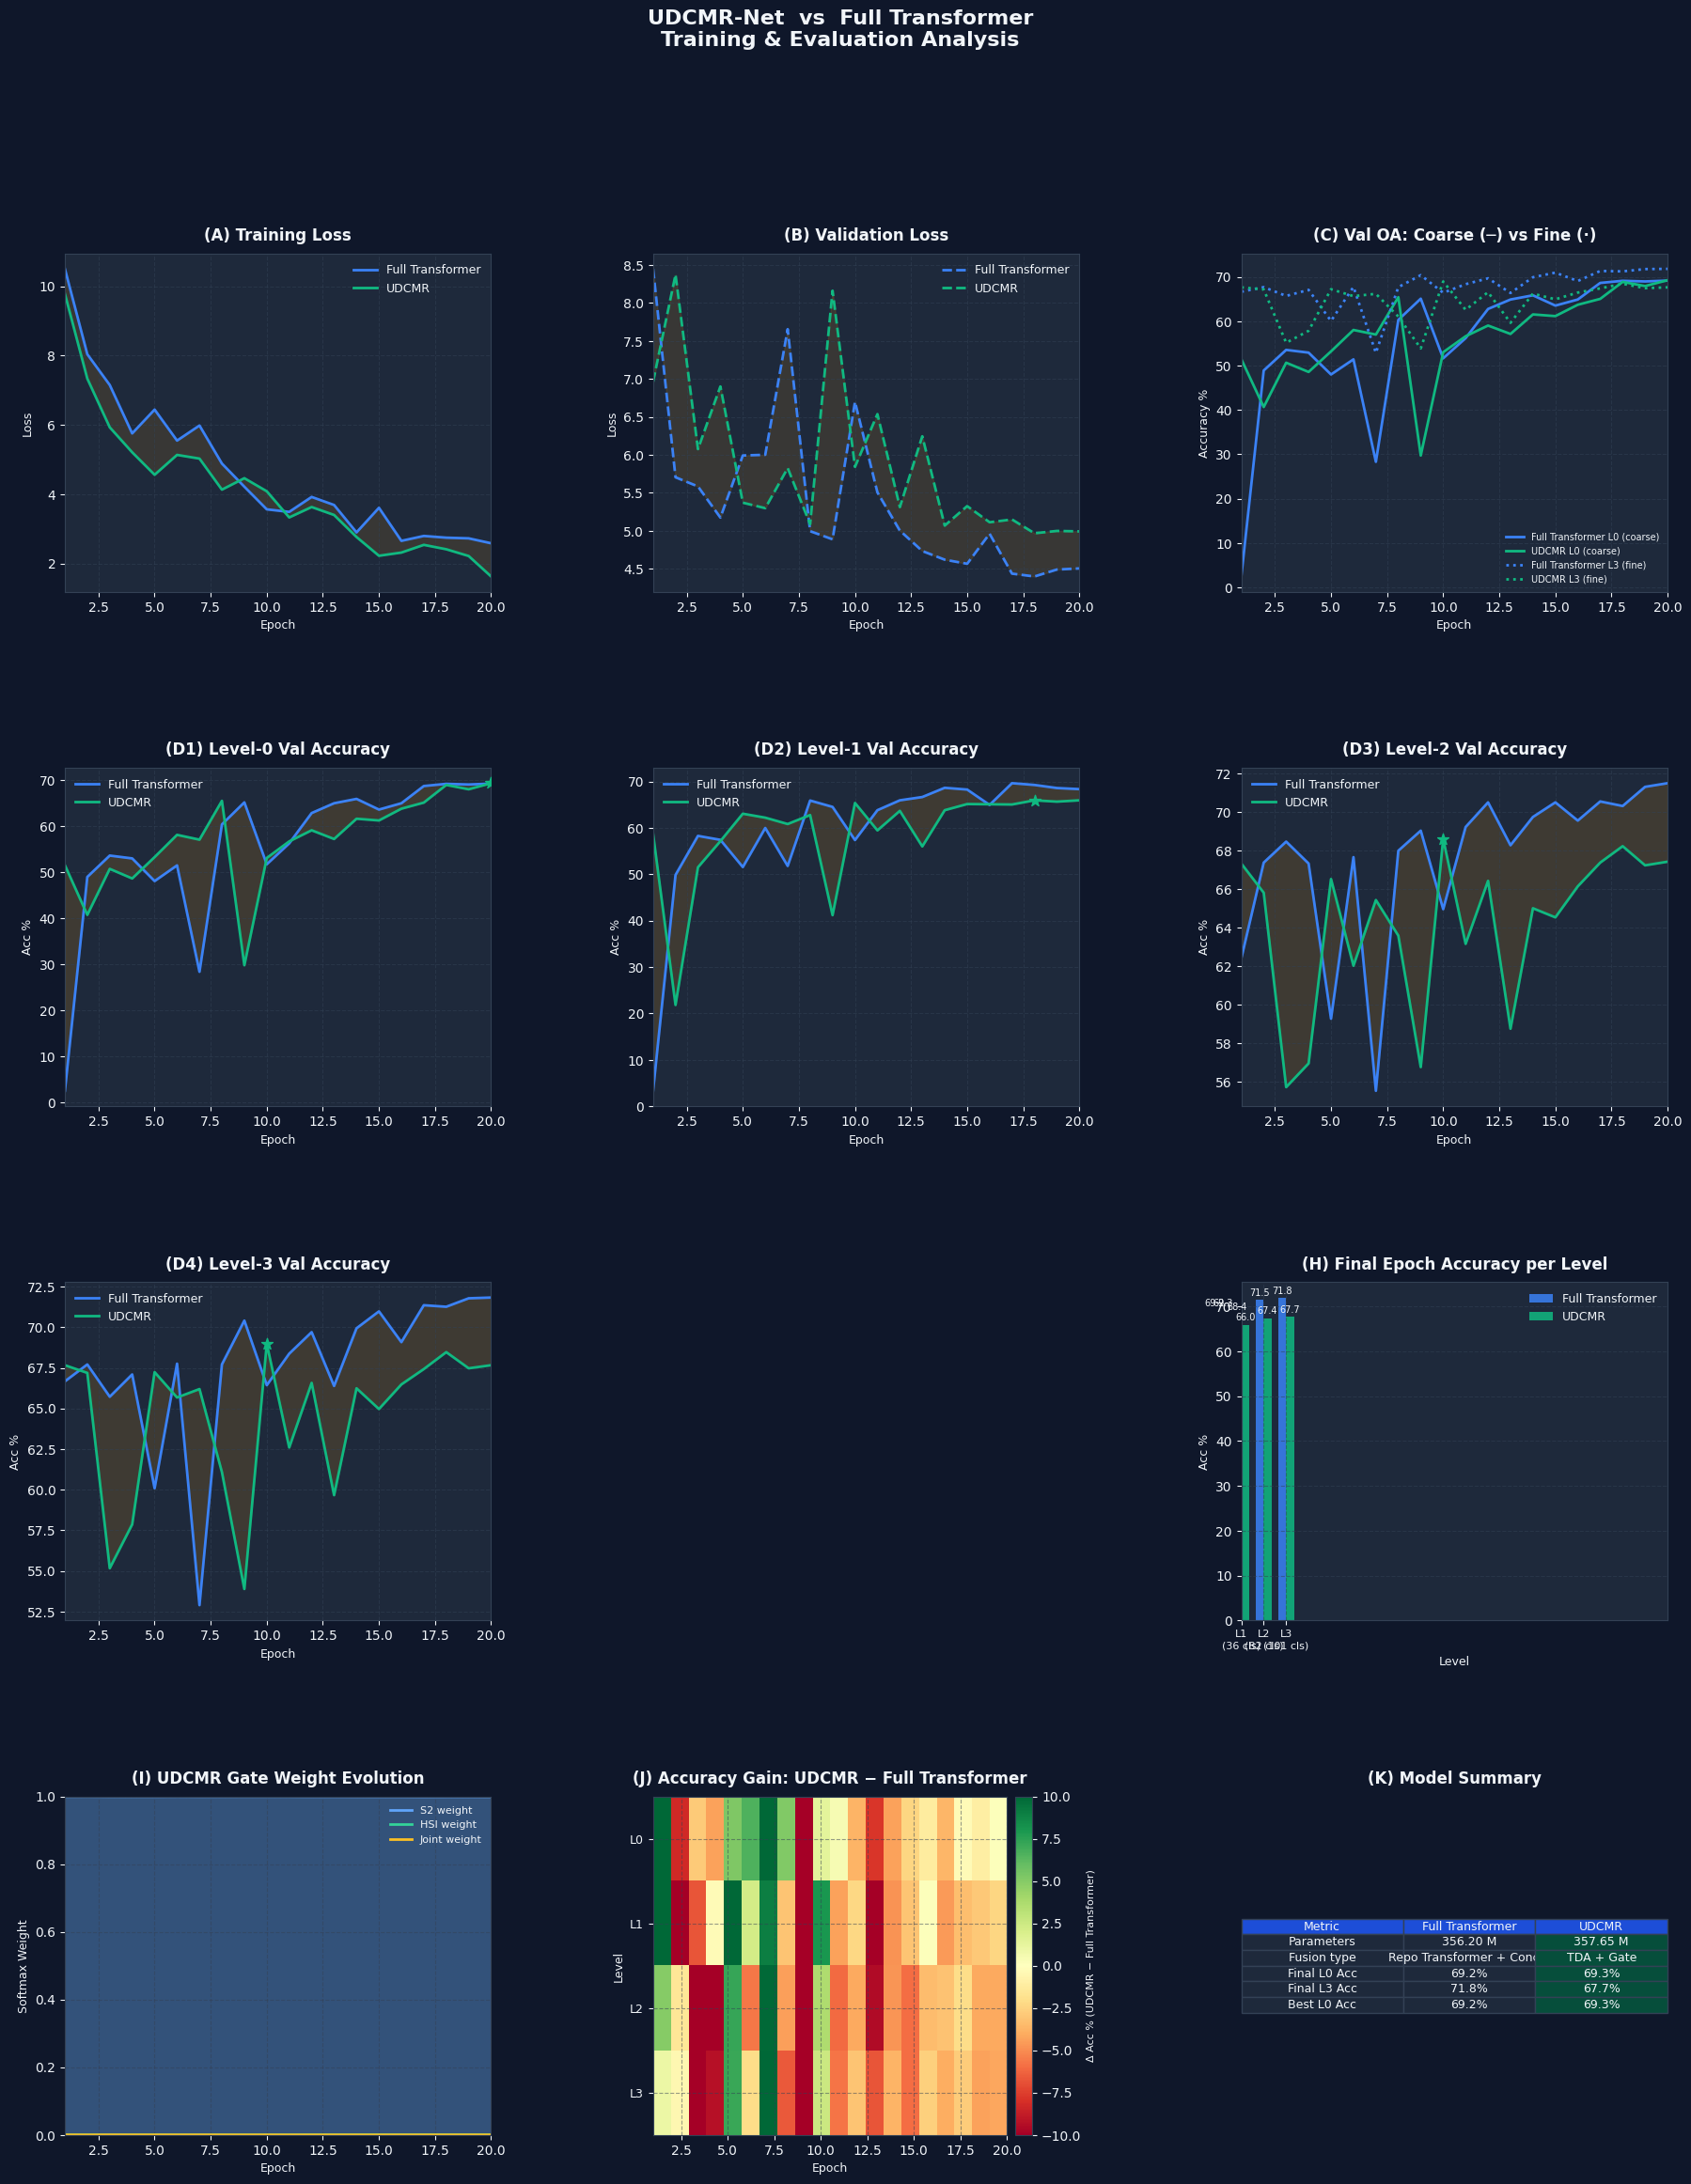


📊 Saved → /home/administrator/Documents/23BAI1010/dataset/saved_models/fusion_comparison.png


In [17]:
# ── Colour palette ────────────────────────────────────────────────────────
C_CONCAT = '#3B82F6'   # blue
C_UDCMR  = '#10B981'   # emerald
C_DIFF   = '#F59E0B'   # amber
C_BG     = '#0F172A'   # slate-900
C_PANEL  = '#1E293B'   # slate-800
C_TEXT   = '#F1F5F9'   # slate-100
C_GRID   = '#334155'   # slate-700

plt.rcParams.update({
    'figure.facecolor' : C_BG,
    'axes.facecolor'   : C_PANEL,
    'axes.edgecolor'   : C_GRID,
    'axes.labelcolor'  : C_TEXT,
    'xtick.color'      : C_TEXT,
    'ytick.color'      : C_TEXT,
    'text.color'       : C_TEXT,
    'grid.color'       : C_GRID,
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlepad'    : 10,
})

epochs = list(range(1, NUM_EPOCHS + 1))


def styled_ax(ax, title, xlabel='Epoch', ylabel=None):
    ax.set_title(title, fontsize=12, fontweight='bold', color=C_TEXT)
    ax.set_xlabel(xlabel, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True)
    ax.set_xlim(1, NUM_EPOCHS)


# ─────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26), facecolor=C_BG)
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.38)

# ── Panel title ──────────────────────────────────────────────────────────
fig.suptitle(
    'UDCMR-Net  vs  Full Transformer\nTraining & Evaluation Analysis',
    fontsize=16, fontweight='bold', color=C_TEXT, y=0.98
)

# ── (A) Training loss ────────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.plot(epochs, fulltransformer_hist['train_loss'], color=C_CONCAT, lw=2, label='Full Transformer')
ax_a.plot(epochs, udcmr_hist ['train_loss'], color=C_UDCMR,  lw=2, label='UDCMR')
ax_a.fill_between(epochs, fulltransformer_hist['train_loss'], udcmr_hist['train_loss'],
                  alpha=0.12, color=C_DIFF)
ax_a.legend(framealpha=0, fontsize=9)
styled_ax(ax_a, '(A) Training Loss', ylabel='Loss')

# ── (B) Validation loss ──────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.plot(epochs, fulltransformer_hist['val_loss'], color=C_CONCAT, lw=2, ls='--', label='Full Transformer')
ax_b.plot(epochs, udcmr_hist ['val_loss'], color=C_UDCMR,  lw=2, ls='--', label='UDCMR')
ax_b.fill_between(epochs, fulltransformer_hist['val_loss'], udcmr_hist['val_loss'],
                  alpha=0.12, color=C_DIFF)
ax_b.legend(framealpha=0, fontsize=9)
styled_ax(ax_b, '(B) Validation Loss', ylabel='Loss')

# ── (C) Val OA — Level 0 (coarsest) ─────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
for li, lbl in [(0, 'L0 (coarse)'), (3, 'L3 (fine)')]:
    ax_c.plot(epochs, [v*100 for v in fulltransformer_hist[f'val_acc_L{li}']],
              color=C_CONCAT, lw=2, ls=('-' if li==0 else ':'),
              label=f'Full Transformer {lbl}')
    ax_c.plot(epochs, [v*100 for v in udcmr_hist[f'val_acc_L{li}']],
              color=C_UDCMR,  lw=2, ls=('-' if li==0 else ':'),
              label=f'UDCMR {lbl}')
ax_c.legend(framealpha=0, fontsize=7)
styled_ax(ax_c, '(C) Val OA: Coarse (─) vs Fine (·)', ylabel='Accuracy %')

# ── (D-G) Per-level val accuracy ─────────────────────────────────────────
for li in range(4):
    col  = li % 3
    row  = 1 + li // 3
    ax   = fig.add_subplot(gs[row, col])
    c_vals = [v * 100 for v in fulltransformer_hist[f'val_acc_L{li}']]
    u_vals = [v * 100 for v in udcmr_hist [f'val_acc_L{li}']]
    ax.plot(epochs, c_vals, color=C_CONCAT, lw=2, label='Full Transformer')
    ax.plot(epochs, u_vals, color=C_UDCMR,  lw=2, label='UDCMR')
    ax.fill_between(epochs, c_vals, u_vals, alpha=0.15, color=C_DIFF)
    best_ep  = int(np.argmax(u_vals))
    ax.scatter(epochs[best_ep], u_vals[best_ep], s=80, color=C_UDCMR,
               zorder=5, marker='*')
    ax.legend(framealpha=0, fontsize=9)
    styled_ax(ax, f'(D{li+1}) Level-{li} Val Accuracy', ylabel='Acc %')

# ── (H) Final-epoch bar chart across all levels ──────────────────────────
ax_h = fig.add_subplot(gs[2, 2])
level_labels = ['L0\n(6 cls)', 'L1\n(36 cls)', 'L2\n(82 cls)', 'L3\n(101 cls)']
c_final = [fulltransformer_hist[f'val_acc_L{li}'][-1] * 100 for li in range(4)]
u_final = [udcmr_hist [f'val_acc_L{li}'][-1] * 100 for li in range(4)]
x       = np.arange(4)
w       = 0.35
bars_c  = ax_h.bar(x - w/2, c_final, w, color=C_CONCAT, label='Full Transformer', alpha=0.85)
bars_u  = ax_h.bar(x + w/2, u_final, w, color=C_UDCMR,  label='UDCMR',  alpha=0.85)
for bar in list(bars_c) + list(bars_u):
    h = bar.get_height()
    ax_h.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}',
              ha='center', va='bottom', fontsize=7, color=C_TEXT)
ax_h.set_xticks(x); ax_h.set_xticklabels(level_labels, fontsize=8)
ax_h.legend(framealpha=0, fontsize=9)
styled_ax(ax_h, '(H) Final Epoch Accuracy per Level', xlabel='Level', ylabel='Acc %')

# ── (I) UDCMR Gate Weight Evolution ──────────────────────────────────────
ax_i = fig.add_subplot(gs[3, 0])
if udcmr_gates:
    gate_arr  = np.array(udcmr_gates)           # (epochs, 3)
    gate_eps  = list(range(1, len(gate_arr) + 1))
    gate_lbls = ['S2 weight', 'HSI weight', 'Joint weight']
    gate_clrs = ['#60A5FA', '#34D399', '#FBBF24']
    for j in range(3):
        ax_i.plot(gate_eps, gate_arr[:, j], color=gate_clrs[j], lw=2, label=gate_lbls[j])
    ax_i.stackplot(gate_eps, gate_arr.T, colors=[c + '55' for c in gate_clrs])
    ax_i.set_ylim(0, 1)
else:
    ax_i.text(0.5, 0.5, 'No gate data\n(Full Transformer model)', ha='center', va='center',
              transform=ax_i.transAxes, fontsize=11, color=C_TEXT)
ax_i.legend(framealpha=0, fontsize=8)
styled_ax(ax_i, '(I) UDCMR Gate Weight Evolution', ylabel='Softmax Weight')

# ── (J) Delta accuracy heatmap (UDCMR − Full Transformer) ──────────────────────────
ax_j = fig.add_subplot(gs[3, 1])
delta = np.array([
    [udcmr_hist[f'val_acc_L{li}'][ep] - fulltransformer_hist[f'val_acc_L{li}'][ep]
     for ep in range(NUM_EPOCHS)]
    for li in range(4)
]) * 100
im = ax_j.imshow(delta, aspect='auto', cmap='RdYlGn',
                 vmin=-10, vmax=10,
                 extent=[1, NUM_EPOCHS, -0.5, 3.5])
ax_j.set_yticks([0, 1, 2, 3])
ax_j.set_yticklabels(['L3', 'L2', 'L1', 'L0'], fontsize=9)
cbar = fig.colorbar(im, ax=ax_j, pad=0.02)
cbar.set_label('Δ Acc % (UDCMR − Full Transformer)', color=C_TEXT, fontsize=8)
cbar.ax.yaxis.set_tick_params(color=C_TEXT)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=C_TEXT)
styled_ax(ax_j, '(J) Accuracy Gain: UDCMR − Full Transformer', ylabel='Level')

# ── (K) Parameter count & model summary ──────────────────────────────────
ax_k = fig.add_subplot(gs[3, 2])
ax_k.axis('off')

c_params = sum(p.numel() for p in fulltransformer_model.parameters())
u_params = sum(p.numel() for p in udcmr_model.parameters())

table_data = [
    ['Metric', 'Full Transformer', 'UDCMR'],
    ['Parameters',      f'{c_params/1e6:.2f} M', f'{u_params/1e6:.2f} M'],
    ['Fusion type',     'Repo Transformer + Concat', 'TDA + Gate'],
    ['Final L0 Acc',    f'{c_final[0]:.1f}%',   f'{u_final[0]:.1f}%'],
    ['Final L3 Acc',    f'{c_final[3]:.1f}%',   f'{u_final[3]:.1f}%'],
    ['Best L0 Acc',
     f"{max(fulltransformer_hist['val_acc_L0'])*100:.1f}%",
     f"{max(udcmr_hist ['val_acc_L0'])*100:.1f}%"],
]
tbl = ax_k.table(cellText=table_data[1:], colLabels=table_data[0],
                 cellLoc='center', loc='center',
                 colWidths=[0.38, 0.31, 0.31])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (r, c_), cell in tbl.get_celld().items():
    cell.set_facecolor(C_PANEL if r > 0 else '#1D4ED8')
    cell.set_text_props(color=C_TEXT)
    cell.set_edgecolor(C_GRID)
    if r > 0 and c_ == 2:
        cell.set_facecolor('#064E3B')
ax_k.set_title('(K) Model Summary', fontsize=12, fontweight='bold',
               color=C_TEXT, pad=10)

plt.savefig(str(SAVE_DIR / 'fusion_comparison.png'),
            dpi=150, bbox_inches='tight', facecolor=C_BG)
# plt.show()
print(f'\n📊 Saved → {SAVE_DIR / "fusion_comparison.png"}')

## 📉 Cell 11 — Confusion Matrix on Test Set (Level 0)

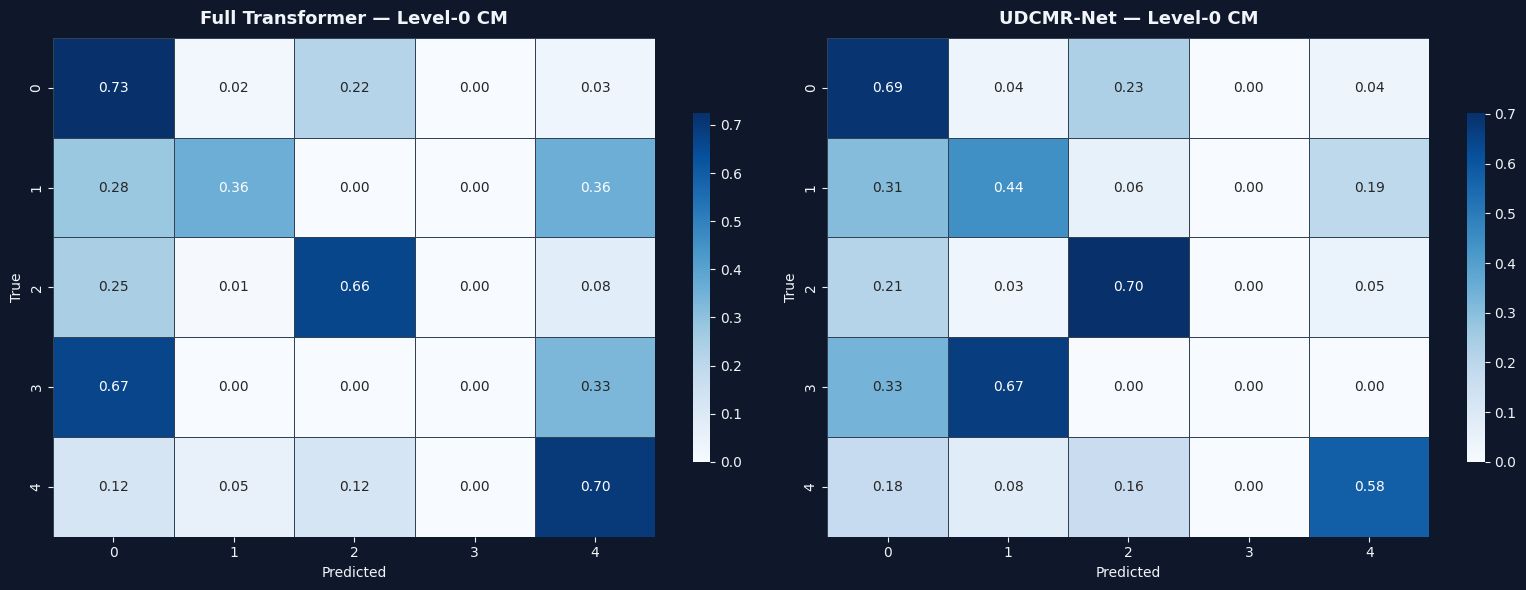

📊 Saved → /home/administrator/Documents/23BAI1010/dataset/saved_models/confusion_matrices.png


In [19]:
@torch.no_grad()
def get_preds_labels(model, loader, level=0):
    model.eval()
    all_preds, all_labels = [], []
    for s2, hsi, lbl in loader:
        s2, hsi = s2.to(device), hsi.to(device)
        out, _  = model(s2, hsi)
        all_preds.append(out[level].argmax(-1).cpu())
        all_labels.append(lbl[:, level])
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()


c_preds, c_true = get_preds_labels(fulltransformer_model, test_dl, level=0)
u_preds, u_true = get_preds_labels(udcmr_model,      test_dl, level=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=C_BG)

for ax, preds, true, title, color in [
    (axes[0], c_preds, c_true, 'Full Transformer — Level-0 CM', C_CONCAT),
    (axes[1], u_preds, u_true, 'UDCMR-Net — Level-0 CM',     C_UDCMR),
]:
    cm   = confusion_matrix(true, preds)
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)
    sns.heatmap(cm_n, ax=ax, cmap='Blues', annot=True, fmt='.2f',
                linewidths=0.5, linecolor=C_GRID,
                cbar_kws={'shrink': 0.7})
    ax.set_title(title, fontsize=13, fontweight='bold', color=C_TEXT)
    ax.set_xlabel('Predicted', color=C_TEXT)
    ax.set_ylabel('True',      color=C_TEXT)
    ax.tick_params(colors=C_TEXT)
    ax.set_facecolor(C_PANEL)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'confusion_matrices.png'),
            dpi=150, bbox_inches='tight', facecolor=C_BG)
# plt.show()
print(f'📊 Saved → {SAVE_DIR / "confusion_matrices.png"}')

## 📋 Cell 12 — Classification Report

In [20]:
print('=' * 55)
print('  Full Transformer — Level-0 Classification Report')
print('=' * 55)
print(classification_report(c_true, c_preds, zero_division=0))

print('=' * 55)
print('  UDCMR-Net — Level-0 Classification Report')
print('=' * 55)
print(classification_report(u_true, u_preds, zero_division=0))

  Full Transformer — Level-0 Classification Report
              precision    recall  f1-score   support

           0       0.71      0.73      0.72       998
           1       0.28      0.36      0.31        36
           3       0.76      0.66      0.71      1106
           4       0.00      0.00      0.00         3
           5       0.27      0.70      0.39        73

    accuracy                           0.69      2216
   macro avg       0.40      0.49      0.43      2216
weighted avg       0.71      0.69      0.70      2216

  UDCMR-Net — Level-0 Classification Report
              precision    recall  f1-score   support

           0       0.73      0.69      0.71       998
           1       0.16      0.44      0.24        36
           3       0.76      0.70      0.73      1106
           4       0.00      0.00      0.00         3
           5       0.30      0.58      0.39        73

    accuracy                           0.69      2216
   macro avg       0.39      0.48   

## 💾 Cell 13 — Save Full Training Histories

In [21]:
import json

histories = {
    'fulltransformer': fulltransformer_hist,
    'udcmr' : udcmr_hist,
    'config': {
        'epochs'    : NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'lr'        : LR,
        'd_model'   : D_MODEL,
        'hierarchy' : HIERARCHY,
    },
}

hist_path = SAVE_DIR / 'training_histories.json'
with open(hist_path, 'w') as jf:
    json.dump(histories, jf, indent=2)

print(f'📝 Histories saved → {hist_path}')
print(f'\nAll artefacts in  {SAVE_DIR}:')
for p in sorted(SAVE_DIR.iterdir()):
    size_kb = p.stat().st_size // 1024
    print(f'   {p.name:45s}  {size_kb:>6} KB')

📝 Histories saved → /home/administrator/Documents/23BAI1010/dataset/saved_models/training_histories.json

All artefacts in  /home/administrator/Documents/23BAI1010/dataset/saved_models:
   FullTransformer_best.pt                        4000627 KB
   FullTransformer_final_ep20.pt                  1391500 KB
   UDCMR_Net_best.pt                              4017602 KB
   UDCMR_Net_final_ep20.pt                        1397159 KB
   confusion_matrices.png                             86 KB
   fusion_comparison.png                             721 KB
   training_histories.json                             6 KB


In [ ]:
# --- Variant dataset + runner: S2-only, S2+EnMAP, S2+Prior, S2+Prior+EnMAP ---
class VariantDataset(Dataset):
    def __init__(self, file_list, augment=False, use_enmap=True, use_prior=False):
        self.file_list = file_list
        self.augment = augment
        self.use_enmap = use_enmap
        self.use_prior = use_prior
        # infer basic shapes from first file when available
        if len(file_list) > 0:
            with h5py.File(file_list[0], 'r') as f:
                s2 = f['S2_data'][:]
                self.T, self.C_s2, self.H, self.W = s2.shape
                if use_enmap and 'EnMAP_data' in f:
                    enmap = f['EnMAP_data'][:]
                    self.enmap_ch = enmap.shape[0] if enmap.ndim == 3 else 1
                else:
                    self.enmap_ch = 218 if use_enmap else 0
                prior_key = None
                for k in ['prior_parcels','prior','prior_map','Prior_map','prior_parcel','Prior']:
                    if k in f:
                        prior_key = k
                        break
                if prior_key and self.use_prior:
                    prior = f[prior_key][:]
                    if prior.ndim == 3:
                        self.prior_ch = prior.shape[0]
                    elif prior.ndim == 2:
                        self.prior_ch = 1
                    else:
                        self.prior_ch = 1
                else:
                    self.prior_ch = 1 if use_prior else 0
        else:
            # sensible defaults if no files available
            self.T, self.C_s2, self.H, self.W = 12, 10, 64, 64
            self.enmap_ch = 218 if use_enmap else 0
            self.prior_ch = 1 if use_prior else 0

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fpath = self.file_list[idx]
        with h5py.File(fpath, 'r') as f:
            s2 = f['S2_data'][:].astype(np.float32)
            label = f['label'][:]
            enmap = f['EnMAP_data'][:].astype(np.float32) if (self.use_enmap and 'EnMAP_data' in f) else None
            prior = None
            if self.use_prior:
                for k in ['prior_parcels','prior','prior_map','Prior_map','prior_parcel','Prior']:
                    if k in f:
                        prior = f[k][:]
                        break
            if enmap is None and self.use_enmap:
                enmap = np.zeros((218, self.H, self.W), dtype=np.float32)
            if prior is None and self.use_prior:
                prior = np.zeros((1, self.H, self.W), dtype=np.float32)
            if self.use_enmap and self.use_prior:
                if prior.ndim == 2:
                    prior = prior[None, ...]
                hsi = np.concatenate([enmap, prior], axis=0)
            elif self.use_enmap:
                hsi = enmap
            elif self.use_prior:
                if prior.ndim == 2:
                    prior = prior[None, ...]
                hsi = prior
            else:
                hsi = np.zeros((1, self.H, self.W), dtype=np.float32)
            # Normalisations
            s2 = (s2 - DualStreamDataset.S2_MEAN[None, :, None, None]) / (DualStreamDataset.S2_STD[None, :, None, None] + 1e-8)
            hsi = (hsi - hsi.mean()) / (hsi.std() + 1e-8)
            if self.augment and np.random.rand() > 0.5:
                s2 = np.flip(s2, axis=-1).copy()
                hsi = np.flip(hsi, axis=-1).copy()
            labs = []
            for li in range(4):
                vals = label[li][label[li] > 0]
                lab  = (int(np.bincount(vals).argmax()) - 1) if len(vals) > 0 else 0
                labs.append(max(0, lab))
            return (torch.from_numpy(s2), torch.from_numpy(hsi), torch.tensor(labs, dtype=torch.long))

def make_dataloaders(use_enmap=True, use_prior=False, batch_size=BATCH_SIZE):
    tr_ds = VariantDataset(train_files, augment=True, use_enmap=use_enmap, use_prior=use_prior)
    val_ds = VariantDataset(val_files, augment=False, use_enmap=use_enmap, use_prior=use_prior)
    test_ds = VariantDataset(test_files, augment=False, use_enmap=use_enmap, use_prior=use_prior) if test_files else val_ds
    # balanced sampler on level-0
    scan_n = min(len(tr_ds), 200)
    l1_labels = [tr_ds[i][2][0].item() for i in range(scan_n)]
    cls_w    = 1.0 / (np.bincount(l1_labels, minlength=HIERARCHY[0]) + 1e-6)
    s_weights = cls_w[l1_labels]
    sampler  = WeightedRandomSampler(s_weights, num_samples=len(s_weights), replacement=True)
    train_dl = DataLoader(tr_ds, batch_size=batch_size, sampler=sampler, num_workers=0)
    val_dl   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    hsi_ch = (tr_ds.enmap_ch if use_enmap else 0) + (tr_ds.prior_ch if use_prior else 0)
    if hsi_ch == 0:
        hsi_ch = 1
    return train_dl, val_dl, test_dl, hsi_ch

def build_model_with_hsi_channels(ModelClass, hsi_in_channels, dropout=0.3):
    model = ModelClass(HIERARCHY, d_model=D_MODEL, dropout=dropout).to(device)
    # replace HSI encoder to match provided channel count
    model.hsi_encoder = RepoTransformerEncoder(img_size=64, in_channels=hsi_in_channels, d_model=D_MODEL, patch_size=16, num_heads=8, num_layers=6, out_size=64).to(device)
    return model

def run_experiment_variant(ModelClass, name: str, color: str, train_dl_v, val_dl_v, test_dl_v, hsi_in_channels=218, weight_decay: float = 1e-4):
    print('\n' + '='*60)
    print('  Training  →  ' + name)
    print('='*60)
    model = build_model_with_hsi_channels(ModelClass, hsi_in_channels)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Parameters: {n_params:,}')
    optimizer = optim.AdamW(model.parameters(), lr=LR_START, weight_decay=weight_decay)
    history = defaultdict(list)
    best_val_f1 = 0.0
    best_ckpt    = SAVE_DIR / (name.replace(' ', '_') + '_best.pt')
    gate_history = []
    total_iters = NUM_EPOCHS * max(1, len(train_dl_v))
    global ITERATION
    ITERATION = 0
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_dl_v, optimizer, criterion, total_iters)
        va_loss, va_acc, gate_w_mean, va_f1_per_level, va_overall_f1 = evaluate(model, val_dl_v, criterion)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['val_f1'].append(va_overall_f1)
        for li in range(4):
            history[f'val_acc_L{li}'].append(va_acc[li])
        if gate_w_mean is not None:
            gate_history.append(gate_w_mean)
        if va_overall_f1 > best_val_f1:
            best_val_f1 = va_overall_f1
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'opt_state'  : optimizer.state_dict(),
                'val_f1'     : best_val_f1,
                'f1_per_level': va_f1_per_level,
                'history'    : dict(history),
            }, best_ckpt)
        elapsed = time.time() - t0
        acc_str = '  '.join(f'L{i}:{va_acc[i]*100:.1f}%' for i in range(4))
        print(f'  Ep {epoch:02d}/{NUM_EPOCHS}  tr_loss={tr_loss:.4f}  va_loss={va_loss:.4f}  ' + f'{acc_str}  F1={va_overall_f1:.4f}  ({elapsed:.1f}s)')
    final_ckpt = SAVE_DIR / (name.replace(' ', '_') + '_final_ep' + str(NUM_EPOCHS) + '.pt')
    torch.save(model.state_dict(), final_ckpt)
    print('\n  💾 Best   model saved → ' + best_ckpt.name)
    print('  💾 Final  model saved → ' + final_ckpt.name)
    return dict(history), gate_history, model

# --- Define variants (uncomment to run training) ---
variants = [
    ('S2-only', False, False),
    ('S2+EnMAP', True, False),
    ('S2+Prior', False, True),
    ('S2+Prior+EnMAP', True, True),
]

variant_results = {}
for vname, use_enmap, use_prior in variants:
    print("\n=== Variant: {} (EnMAP={}, Prior={}) ===".format(vname, use_enmap, use_prior))
    tdl, vdl, tstdl, hsi_ch = make_dataloaders(use_enmap=use_enmap, use_prior=use_prior)
    ud_name = 'UDCMR_' + vname.replace('+','_').replace(' ','')
    ud_hist, ud_gates, ud_model = run_experiment_variant(UDCMR_Net, ud_name, '#10B981', tdl, vdl, tstdl, hsi_in_channels=hsi_ch)
    variant_results[vname] = {
        'udcmr': {'hist': ud_hist, 'model': ud_model},
        'gates': ud_gates,
    }

# --- Summary visualization (UDCMR best-val F1 per variant) ---
if len(variant_results):
    labels = list(variant_results.keys())
    best_ud = [max(variant_results[v]['udcmr']['hist']['val_f1']) for v in labels]
    fig, ax = plt.subplots(figsize=(10,4))
    x = np.arange(len(labels))
    ax.bar(x, np.array(best_ud) * 100, width=0.6, color=C_UDCMR)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel('Best Val F1 (%)')
    ax.set_title('UDCMR — Best Val F1 per Variant')
    plt.tight_layout()
    plt.savefig(str(SAVE_DIR / 'variant_udcmr_f1_comparison.png'), dpi=150)
    # plt.show()
    print('Saved variant summary → ' + str(SAVE_DIR / 'variant_udcmr_f1_comparison.png'))